# 02 Feature Engineering: Mock Pharma Trial Response Model

This notebook builds on `01_initial_experiment.ipynb`.

The objective is to create clinically plausible engineered features and test whether they improve model performance.

This notebook covers:

1. Loading the synthetic trial dataset
2. Creating engineered features
3. Comparing raw features versus engineered features
4. Tracking the comparison in MLflow
5. Saving an engineered-feature model candidate

This is demo/portfolio code only. It does not use real patient data and must not be used for medical decision-making.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Project root:", PROJECT_ROOT)
print("Source path:", SRC_PATH)
print("Package exists:", (SRC_PATH / "pharma_trial_ml").exists())

Project root: /home/raither/projects/MOCKPHARMA
Source path: /home/raither/projects/MOCKPHARMA/src
Package exists: True


In [2]:
import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from pharma_trial_ml.config import (
    DATA_PATH,
    DATA_DIR,
    MODEL_DIR,
    EXPERIMENT_NAME,
    MLFLOW_TRACKING_URI,
)
from pharma_trial_ml.data import generate_mock_trial_data
from pharma_trial_ml.features import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET,
    build_preprocessor,
)

## 2. Load dataset

In [3]:
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    df = generate_mock_trial_data(n_rows=2500, random_state=42)
    df.to_csv(DATA_PATH, index=False)

df.head()

,age,bmi,baseline_biomarker,dose_mg,adherence_pct,prior_treatments,sex,trial_arm,responder
0,58.7,30.8,55.36,50,98.3,2,M,placebo,0
1,42.5,29.2,54.61,25,52.7,2,M,active,0
2,64.0,33.0,47.46,25,100.0,1,M,placebo,0
3,66.3,30.4,67.71,10,93.6,2,M,active,0
4,31.6,34.1,64.22,25,100.0,1,M,active,1


## 3. Feature engineering function

The feature engineering below is deliberately simple and explainable.

The new features are:

- `dose_adherence_exposure`: approximates actual exposure by multiplying dose by adherence
- `biomarker_per_dose`: baseline biomarker relative to dose
- `high_adherence`: binary flag for adherence above 90%
- `older_patient`: binary flag for age 65+
- `high_bmi`: binary flag for BMI 30+
- `multiple_prior_treatments`: binary flag for previous treatment burden
- `active_high_adherence`: interaction between active arm and high adherence
- `age_group`: categorical age band
- `bmi_group`: categorical BMI band
- `biomarker_group`: categorical biomarker band
- `adherence_group`: categorical adherence band

The target column is not used in feature creation, so there is no target leakage.

In [4]:
def engineer_features(input_df: pd.DataFrame) -> pd.DataFrame:
    df_fe = input_df.copy()

    df_fe["dose_adherence_exposure"] = df_fe["dose_mg"] * (df_fe["adherence_pct"] / 100)
    df_fe["biomarker_per_dose"] = df_fe["baseline_biomarker"] / (df_fe["dose_mg"] + 1)
    df_fe["high_adherence"] = (df_fe["adherence_pct"] >= 90).astype(int)
    df_fe["older_patient"] = (df_fe["age"] >= 65).astype(int)
    df_fe["high_bmi"] = (df_fe["bmi"] >= 30).astype(int)
    df_fe["multiple_prior_treatments"] = (df_fe["prior_treatments"] >= 2).astype(int)

    df_fe["active_high_adherence"] = (
        (df_fe["trial_arm"] == "active") & (df_fe["adherence_pct"] >= 90)
    ).astype(int)

    df_fe["age_group"] = pd.cut(
        df_fe["age"],
        bins=[17, 40, 55, 65, 100],
        labels=["18_40", "41_55", "56_65", "66_plus"],
    ).astype(str)

    df_fe["bmi_group"] = pd.cut(
        df_fe["bmi"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["underweight", "normal", "overweight", "obese"],
    ).astype(str)

    df_fe["biomarker_group"] = pd.cut(
        df_fe["baseline_biomarker"],
        bins=[0, 40, 60, 80, 200],
        labels=["low", "medium", "high", "very_high"],
    ).astype(str)

    df_fe["adherence_group"] = pd.cut(
        df_fe["adherence_pct"],
        bins=[0, 70, 85, 95, 100],
        labels=["low", "medium", "high", "very_high"],
        include_lowest=True,
    ).astype(str)

    return df_fe

In [5]:
df_fe = engineer_features(df)

FEATURED_DATA_PATH = DATA_DIR / "mock_trial_features.csv"
df_fe.to_csv(FEATURED_DATA_PATH, index=False)

df_fe.head()

,age,bmi,baseline_biomarker,dose_mg,adherence_pct,prior_treatments,sex,trial_arm,responder,dose_adherence_exposure,biomarker_per_dose,high_adherence,older_patient,high_bmi,multiple_prior_treatments,active_high_adherence,age_group,bmi_group,biomarker_group,adherence_group
0,58.7,30.8,55.36,50,98.3,2,M,placebo,0,49.150,1.085490,1,0,1,1,0,56_65,obese,medium,very_high
1,42.5,29.2,54.61,25,52.7,2,M,active,0,13.175,2.100385,0,0,0,1,0,41_55,overweight,medium,low
2,64.0,33.0,47.46,25,100.0,1,M,placebo,0,25.000,1.825385,1,0,1,0,0,56_65,obese,medium,very_high
3,66.3,30.4,67.71,10,93.6,2,M,active,0,9.360,6.155455,1,1,1,1,1,66_plus,obese,high,high
4,31.6,34.1,64.22,25,100.0,1,M,active,1,25.000,2.470000,1,0,1,0,1,18_40,obese,high,very_high


## 4. Define raw and engineered feature sets

In [6]:
raw_numeric_features = NUMERIC_FEATURES
raw_categorical_features = CATEGORICAL_FEATURES

engineered_numeric_features = NUMERIC_FEATURES + [
    "dose_adherence_exposure",
    "biomarker_per_dose",
    "high_adherence",
    "older_patient",
    "high_bmi",
    "multiple_prior_treatments",
    "active_high_adherence",
]

engineered_categorical_features = CATEGORICAL_FEATURES + [
    "age_group",
    "bmi_group",
    "biomarker_group",
    "adherence_group",
]

raw_feature_columns = raw_numeric_features + raw_categorical_features
engineered_feature_columns = engineered_numeric_features + engineered_categorical_features

print("Raw feature count:", len(raw_feature_columns))
print("Engineered feature count:", len(engineered_feature_columns))

Raw feature count: 8
Engineered feature count: 19


## 5. Build preprocessing pipelines

In [7]:
def build_custom_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )


def build_model_pipeline(model_type, numeric_features, categorical_features):
    preprocessor = build_custom_preprocessor(numeric_features, categorical_features)

    if model_type == "logistic_regression":
        classifier = LogisticRegression(
            max_iter=1000,
            C=1.0,
            class_weight="balanced",
        )
    elif model_type == "random_forest":
        classifier = RandomForestClassifier(
            n_estimators=250,
            max_depth=7,
            min_samples_leaf=6,
            random_state=42,
            class_weight="balanced",
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )


def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }

## 6. Train/test split

In [8]:
X_raw = df[raw_feature_columns]
X_engineered = df_fe[engineered_feature_columns]
y = df[TARGET]

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_fe_train, X_fe_test, _, _ = train_test_split(
    X_engineered,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_raw_train.shape, X_fe_train.shape

((1875, 8), (1875, 19))

## 7. Compare raw versus engineered features in MLflow

In [9]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

experiments = [
    {
        "run_name": "02_raw_logistic_regression",
        "feature_set": "raw",
        "model_type": "logistic_regression",
        "X_train": X_raw_train,
        "X_test": X_raw_test,
        "numeric_features": raw_numeric_features,
        "categorical_features": raw_categorical_features,
    },
    {
        "run_name": "02_raw_random_forest",
        "feature_set": "raw",
        "model_type": "random_forest",
        "X_train": X_raw_train,
        "X_test": X_raw_test,
        "numeric_features": raw_numeric_features,
        "categorical_features": raw_categorical_features,
    },
    {
        "run_name": "02_engineered_logistic_regression",
        "feature_set": "engineered",
        "model_type": "logistic_regression",
        "X_train": X_fe_train,
        "X_test": X_fe_test,
        "numeric_features": engineered_numeric_features,
        "categorical_features": engineered_categorical_features,
    },
    {
        "run_name": "02_engineered_random_forest",
        "feature_set": "engineered",
        "model_type": "random_forest",
        "X_train": X_fe_train,
        "X_test": X_fe_test,
        "numeric_features": engineered_numeric_features,
        "categorical_features": engineered_categorical_features,
    },
]

results = []
best_model = None
best_run_id = None
best_details = None
best_f1 = -1

for exp in experiments:
    model = build_model_pipeline(
        model_type=exp["model_type"],
        numeric_features=exp["numeric_features"],
        categorical_features=exp["categorical_features"],
    )

    with mlflow.start_run(run_name=exp["run_name"]) as run:
        model.fit(exp["X_train"], y_train)
        metrics = evaluate_model(model, exp["X_test"], y_test)

        mlflow.log_param("notebook", "02_feature_engineering")
        mlflow.log_param("feature_set", exp["feature_set"])
        mlflow.log_param("model_type", exp["model_type"])
        mlflow.log_param("numeric_feature_count", len(exp["numeric_features"]))
        mlflow.log_param("categorical_feature_count", len(exp["categorical_features"]))
        mlflow.log_metrics(metrics)

        # Save plots
        fig, ax = plt.subplots()
        ConfusionMatrixDisplay.from_estimator(model, exp["X_test"], y_test, ax=ax)
        ax.set_title(exp["run_name"])
        confusion_path = MODEL_DIR / f"{exp['run_name']}_confusion_matrix.png"
        fig.savefig(confusion_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(confusion_path), artifact_path="plots")

        fig, ax = plt.subplots()
        RocCurveDisplay.from_estimator(model, exp["X_test"], y_test, ax=ax)
        ax.set_title(exp["run_name"])
        roc_path = MODEL_DIR / f"{exp['run_name']}_roc_curve.png"
        fig.savefig(roc_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(roc_path), artifact_path="plots")

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            input_example=exp["X_test"].head(3),
        )

        row = {
            "run_id": run.info.run_id,
            "run_name": exp["run_name"],
            "feature_set": exp["feature_set"],
            "model_type": exp["model_type"],
            **metrics,
        }

        results.append(row)

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_model = model
            best_run_id = run.info.run_id
            best_details = row

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

,run_id,run_name,feature_set,model_type,accuracy,precision,recall,f1,roc_auc
1,090de12b99e64088bbe91f3656e740dd,02_raw_random_forest,raw,random_forest,0.7680,0.427778,0.647059,0.515050,0.786761
0,c62b094711ef475485e5b3d5f132f204,02_raw_logistic_regression,raw,logistic_regression,0.7312,0.388128,0.714286,0.502959,0.802903
2,8446bda789c141fbad08cb4d084f377d,02_engineered_logistic_regression,engineered,logistic_regression,0.7296,0.384259,0.697479,0.495522,0.800196
3,c180cdd900dc4cc6a9907efab52b758b,02_engineered_random_forest,engineered,random_forest,0.7616,0.413793,0.605042,0.491468,0.784220


## 8. Save best engineered-feature candidate

In [10]:
FEATURE_ENGINEERED_MODEL_PATH = MODEL_DIR / "trial_response_feature_engineered_model.joblib"
FEATURE_ENGINEERED_METADATA_PATH = MODEL_DIR / "feature_engineered_model_metadata.json"

joblib.dump(best_model, FEATURE_ENGINEERED_MODEL_PATH)

metadata = {
    "model_path": str(FEATURE_ENGINEERED_MODEL_PATH),
    "best_run_id": best_run_id,
    "best_details": best_details,
    "raw_features": raw_feature_columns,
    "engineered_features": engineered_feature_columns,
    "target": TARGET,
    "feature_engineering_notes": [
        "No target leakage used.",
        "Features are simple synthetic clinical-style transformations.",
        "This is a portfolio/demo project only.",
    ],
}

FEATURE_ENGINEERED_METADATA_PATH.write_text(json.dumps(metadata, indent=2))

metadata

{'model_path': '/home/raither/projects/MOCKPHARMA/models/trial_response_feature_engineered_model.joblib',
 'best_run_id': '090de12b99e64088bbe91f3656e740dd',
 'best_details': {'run_id': '090de12b99e64088bbe91f3656e740dd',
  'run_name': '02_raw_random_forest',
  'feature_set': 'raw',
  'model_type': 'random_forest',
  'accuracy': 0.768,
  'precision': 0.42777777777777776,
  'recall': 0.6470588235294118,
  'f1': 0.5150501672240803,
  'roc_auc': np.float64(0.7867605540239812)},
 'raw_features': ['age',
  'bmi',
  'baseline_biomarker',
  'dose_mg',
  'adherence_pct',
  'prior_treatments',
  'sex',
  'trial_arm'],
 'engineered_features': ['age',
  'bmi',
  'baseline_biomarker',
  'dose_mg',
  'adherence_pct',
  'prior_treatments',
  'dose_adherence_exposure',
  'biomarker_per_dose',
  'high_adherence',
  'older_patient',
  'high_bmi',
  'multiple_prior_treatments',
  'active_high_adherence',
  'sex',
  'trial_arm',
  'age_group',
  'bmi_group',
  'biomarker_group',
  'adherence_group'],
 't

## 9. Inspect feature importance for random forest

In [11]:
if best_details["model_type"] == "random_forest":
    preprocessor = best_model.named_steps["preprocessor"]
    classifier = best_model.named_steps["classifier"]

    feature_names = preprocessor.get_feature_names_out()
    importances = classifier.feature_importances_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20)
    )

    importance_df
else:
    print("Best model is not a random forest, so tree-based feature importance is not available.")

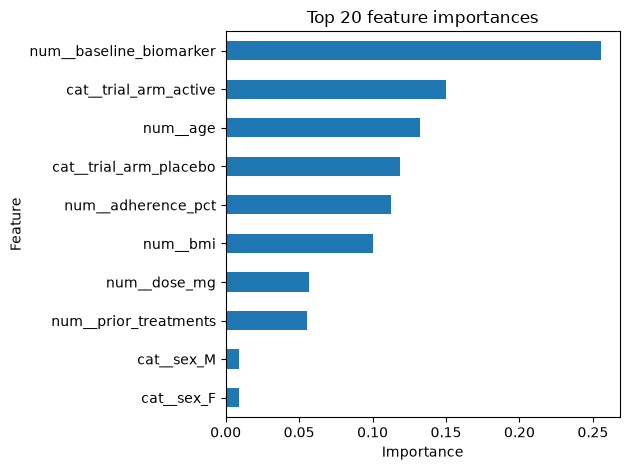

In [12]:
if best_details["model_type"] == "random_forest":
    ax = importance_df.sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
    )
    ax.set_title("Top 20 feature importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()